<a href="https://colab.research.google.com/github/241501239/241501239-fdva-exp-1-7/blob/main/Copy_of_Untitled13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(value=50, min=0, max=1000, step=1, description='Value:')
output = widgets.Output()

def on_value_change(change):
    output.clear_output()
    with output:
        print(f'Slider value is {change["new"]}')

slider.observe(on_value_change, names='value')
display(slider, output)

IntSlider(value=50, description='Value:', max=1000)

Output()

In [ ]:
import pandas as pd
import requests
import io

# Using a file that exists in the Colab environment
csv_path = "/content/sample_data/california_housing_train.csv"
df_csv = pd.read_csv(csv_path)
display(df_csv.head())

# Loading data from a URL with a User-Agent to avoid 403 Forbidden errors
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36"
}

r = requests.get(url, headers=header)
# Using StringIO to wrap the HTML string to avoid the FutureWarning
tables = pd.read_html(io.StringIO(r.text))
df_web = tables[2] # Using index 2 for the main GDP table
display(df_web.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

Missing Values: 0


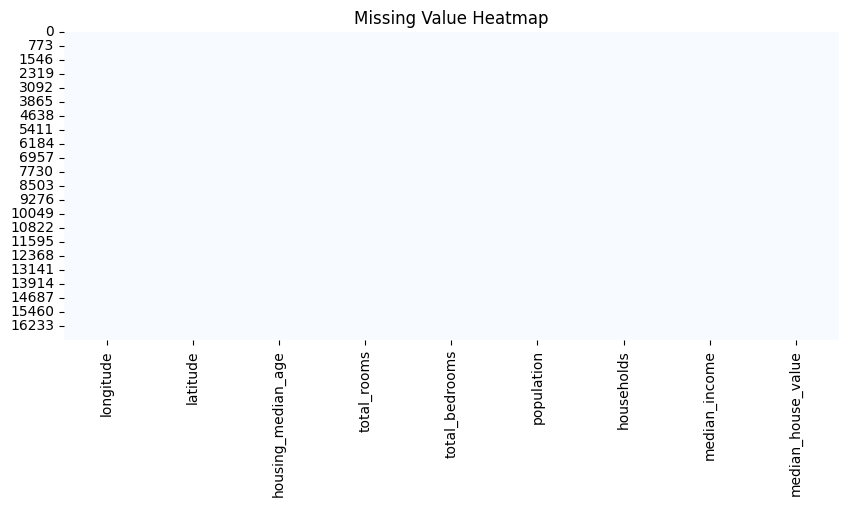

Removed 0 duplicate rows.

Cleaned Data Summary:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,0.147885,0.198945,0.028364,472.0,-1.252543,66900.0
1,-114.47,34.40,19.0,0.201608,0.294848,0.031559,463.0,-1.081483,80100.0
2,-114.56,33.69,17.0,0.018927,0.026847,0.009249,117.0,-1.170105,85700.0
3,-114.57,33.64,14.0,0.039515,0.052142,0.014350,226.0,-0.362600,73400.0
4,-114.57,33.57,20.0,0.038276,0.050435,0.017405,262.0,-1.026454,65500.0


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import os

# Using the available sample data since the previous file was missing
file_path = '/content/sample_data/california_housing_train.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    print("Initial Data Overview:")
    df.info()

    # 1. Handling Missing Values
    print("\nMissing Values:", df.isnull().sum().sum())
    plt.figure(figsize=(10,4))
    sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
    plt.title("Missing Value Heatmap")
    plt.show()

    # 2. Removing Duplicates
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

    # 3. Scaling numerical columns
    # Selecting columns common to this dataset for demonstration
    scale_cols = ['total_rooms', 'total_bedrooms', 'population']
    min_max_scaler = MinMaxScaler()
    df[scale_cols] = min_max_scaler.fit_transform(df[scale_cols])

    scaler = StandardScaler()
    df[['median_income']] = scaler.fit_transform(df[['median_income']])

    print("\nCleaned Data Summary:")
    display(df.head())
else:
    print(f"File not found: {file_path}")

In [ ]:
import pandas as pd
import os

# Updated to use a file that exists in the environment
file_path = '/content/sample_data/california_housing_train.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(df.head())
    print(df.tail())
    print(df.info())
    print(df.describe())
    print(df.columns)

    # Demonstrate loop with proper indentation using available columns
    sample_cols = ['housing_median_age', 'median_house_value']

    for col in sample_cols:
        unique_vals = df[col].unique()
        print(f"\nUnique values in '{col}': {len(unique_vals)} unique entries")

    # Statistics loop with proper indentation
    stat_cols = ['total_rooms', 'total_bedrooms', 'population']

    for col in stat_cols:
        print(f"\nStatistics for '{col}':")
        print(f"Mean: {df[col].mean():.2f}")
        print(f"Median: {df[col].median():.2f}")
        print(f"Range: {df[col].max() - df[col].min():.2f}")
        print(f"Standard Deviation: {df[col].std():.2f}")
else:
    print(f"File not found: {file_path}")

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


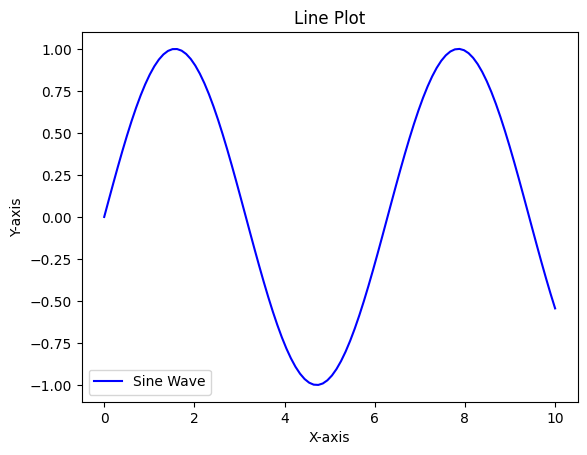

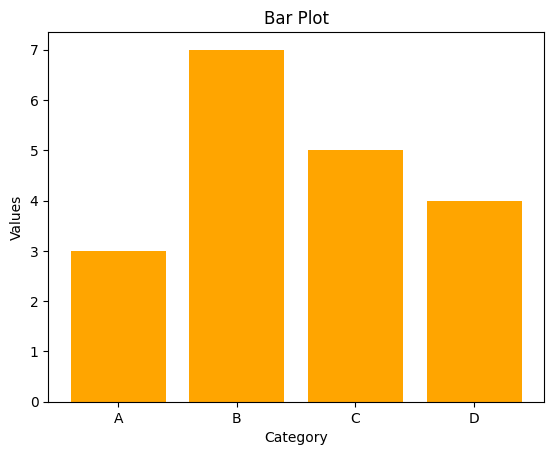

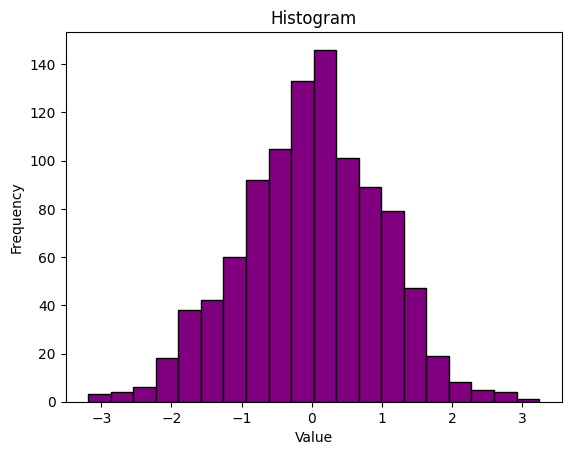

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Using existing sample data to avoid file missing errors
file_path = "/content/sample_data/california_housing_train.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    display(df.head())

# --- LINE CHART ---
x = np.linspace(0, 10, 100)
y = np.sin(x)
plt.figure()
plt.plot(x, y, color='blue', label='Sine Wave')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Line Plot')
plt.legend()
plt.show()

# --- BAR CHART ---
categories = ['A', 'B', 'C', 'D']
values = [3, 7, 5, 4]
plt.figure()
plt.bar(categories, values, color='orange')
plt.xlabel('Category')
plt.ylabel('Values')
plt.title('Bar Plot')
plt.show()

# --- HISTOGRAM ---
data = np.random.randn(1000)
plt.figure()
plt.hist(data, bins=20, color='purple', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()